In [256]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [257]:
4**249<5**210

False

In [258]:
!ls ../public/data

aqi_shanghai.csv  derived  weather_shanghai.csv  weather_shanghai2.csv


In [259]:
weather_fp = '../public/data/weather_shanghai2.csv'
df_weather = pd.read_csv(weather_fp)
aqi_fp = '../public/data/aqi_shanghai.csv'
df_aqi = pd.read_csv(aqi_fp)

## Weather data

In [260]:
!pwd

/home/ginger/code/gderiddershanghai/shanghai-weather-app/Nbs


In [261]:
import sys
sys.path.append("..")

from src.analysis_py.temperature_datasets import TempConfig, compute_temperature_tables

df = pd.read_csv(weather_fp)
cfg = TempConfig(smooth_window_days=15, heat_q=0.99, cold_q=0.01, min_event_days=3)

df_daily, df_clim, df_enriched, df_outliers, df_events = compute_temperature_tables(df, cfg)

In [269]:
df_daily[(df_daily['month'].isin([10]))& (df_daily['year'].isin([2025]))][['date','temperature_2m_max', 'apparent_temperature_max']]

,date,temperature_2m_max,apparent_temperature_max
16710,2025-10-01,27.3,30.8
16711,2025-10-02,31.0,34.5
16712,2025-10-03,30.8,36.6
16713,2025-10-04,30.5,35.3
16714,2025-10-05,33.1,39.3
16715,2025-10-06,36.4,40.8
16716,2025-10-07,32.9,37.2
16717,2025-10-08,29.9,31.9
16718,2025-10-09,30.1,32.2
16719,2025-10-10,33.2,37.1


In [263]:
summers = df_daily[(df_daily['month'].isin([6,7,8,9]))][['date','temperature_2m_mean', 'apparent_temperature_max', 'year']]
summers.groupby('year').mean()[['temperature_2m_mean', 'apparent_temperature_max']].sort_values(by='temperature_2m_mean', ascending=False)

,temperature_2m_mean,apparent_temperature_max
year,,
2025,28.422131,37.160656
2024,27.790984,36.418852
2022,27.299180,35.792623
2013,27.257377,34.729508
2005,26.703279,34.295082
2007,26.600820,34.320492
2023,26.562295,34.947541
2017,26.548361,34.527049
2003,26.526230,34.608197


In [264]:
winters = df_daily[(df_daily['month'].isin([11,12,1,2]))][['date','temperature_2m_mean', 'apparent_temperature_min', 'year']]
winters.groupby('year').mean()[['temperature_2m_mean', 'apparent_temperature_min']].sort_values(by='temperature_2m_mean')

,temperature_2m_mean,apparent_temperature_min
year,,
1981,5.671667,-1.786667
1980,6.070248,-1.164463
1984,6.251240,-0.555372
2005,6.404167,-0.564167
2012,6.503306,-0.678512
1983,6.633333,-0.793333
2008,6.646281,-0.768595
1985,6.654167,-0.358333
1986,6.731667,-0.476667


In [265]:
winter_month = df_daily[(df_daily['month'].isin([11,12,1,2]))][['date','temperature_2m_mean', 'apparent_temperature_min', 'year', 'month']]
winter_month.groupby(['year', 'month']).mean()[['temperature_2m_mean', 'apparent_temperature_min']].sort_values(by='temperature_2m_mean')

,,temperature_2m_mean,apparent_temperature_min
year,month,,
2011,1,1.141935,-6.935484
1981,1,1.696774,-6.103226
1984,1,1.800000,-5.977419
1980,2,1.927586,-5.927586
2005,1,2.777419,-5.003226
1984,2,2.889655,-4.368966
2008,2,3.331034,-5.027586
1980,1,3.335484,-4.277419
2003,1,3.354839,-4.967742


In [266]:
pd.set_option('display.max_rows', 600)

df_daily[(df_daily['year']==2010)&(df_daily['month'].isin([12]))][['date','temperature_2m_min', 'apparent_temperature_min']]

,date,temperature_2m_min,apparent_temperature_min
11292,2010-12-01,8.8,8.3
11293,2010-12-02,12.0,8.4
11294,2010-12-03,6.0,2.4
11295,2010-12-04,5.4,2.3
11296,2010-12-05,9.5,7.7
11297,2010-12-06,6.2,1.1
11298,2010-12-07,1.0,-2.7
11299,2010-12-08,0.6,-3.4
11300,2010-12-09,2.7,-0.7
11301,2010-12-10,8.0,3.4


In [229]:
df_daily[['date','temperature_2m_min', 'apparent_temperature_min']].sort_values(by='temperature_2m_min', ascending=True).head(50)

,date,temperature_2m_min,apparent_temperature_min
30,1980-01-31,-11.1,-17.7
31,1980-02-01,-9.1,-14.6
35,1980-02-05,-8.9,-14.9
14983,2021-01-08,-8.7,-15.6
29,1980-01-30,-8.6,-16.2
13172,2016-01-24,-8.5,-17.5
36,1980-02-06,-8.4,-13.3
2196,1986-01-05,-8.1,-14.8
14982,2021-01-07,-7.8,-14.6
39,1980-02-09,-7.8,-12.7


In [162]:
cols = ['temperature_2m_min', 'apparent_temperature_min']
df_daily.sort_values(by=cols[0], ascending=True).head(20)[['date', 'year', 'month', 'day','doy','temperature_2m_min', 'apparent_temperature_min']]

,date,year,month,day,doy,temperature_2m_min,apparent_temperature_min
30,1980-01-31,1980,1,31,31,-11.1,-17.7
31,1980-02-01,1980,2,1,32,-9.1,-14.6
35,1980-02-05,1980,2,5,36,-8.9,-14.9
14983,2021-01-08,2021,1,8,8,-8.7,-15.6
29,1980-01-30,1980,1,30,30,-8.6,-16.2
13172,2016-01-24,2016,1,24,24,-8.5,-17.5
36,1980-02-06,1980,2,6,37,-8.4,-13.3
2196,1986-01-05,1986,1,5,5,-8.1,-14.8
14982,2021-01-07,2021,1,7,7,-7.8,-14.6
39,1980-02-09,1980,2,9,40,-7.8,-12.7


In [185]:
top_dates1 = df_daily.sort_values(by=cols[0], ascending=True).head(50)['date'].values
top_dates2 = df_daily.sort_values(by=cols[1], ascending=True).head(50)['date'].values

In [206]:
top_dates = [i for i in top_dates2 if i in top_dates1]
df_daily[df_daily['date'].isin(top_dates)][['date', 'year', 'month', 'day','doy','temperature_2m_min', 'apparent_temperature_min']].sort_values(by='apparent_temperature_min', ascending=True)

,date,year,month,day,doy,temperature_2m_min,apparent_temperature_min
30,1980-01-31,1980,1,31,31,-11.1,-17.7
13172,2016-01-24,2016,1,24,24,-8.5,-17.5
29,1980-01-30,1980,1,30,30,-8.6,-16.2
14983,2021-01-08,2021,1,8,8,-8.7,-15.6
35,1980-02-05,1980,2,5,36,-8.9,-14.9
2196,1986-01-05,1986,1,5,5,-8.1,-14.8
4379,1991-12-28,1991,12,28,362,-6.8,-14.7
31,1980-02-01,1980,2,1,32,-9.1,-14.6
14982,2021-01-07,2021,1,7,7,-7.8,-14.6
13173,2016-01-25,2016,1,25,25,-7.3,-13.8


In [133]:
df_clim.sort_values(by='atmax_spread_p99_p50', ascending=False).head(20)

,doy,tmax_p50,tmax_p95,tmax_p99,tmin_p50,tmin_p05,tmin_p01,tmax_p50_sm15,tmax_p95_sm15,tmax_p99_sm15,...,atmin_p50_sm15,atmin_p05_sm15,atmin_p01_sm15,atmax_spread_p99_p50,atmax_spread_p99_p50_sm15,atmin_spread_p50_p01,atmin_spread_p50_p01_sm15,date_ref,month_ref,day_ref
12,13,7.45,16.425,19.300,1.40,-5.175,-6.115,8.210000,14.936667,17.585333,...,-3.046667,-9.095000,-10.892333,17.290,11.980667,9.490,7.845667,2001-01-13,1,13
43,44,9.60,22.100,24.170,2.80,-3.875,-4.055,9.243333,17.396667,20.573667,...,-1.790000,-7.613333,-9.184000,17.210,13.789000,7.770,7.394000,2001-02-13,2,13
60,61,10.30,16.600,24.415,2.90,-1.350,-3.055,11.110000,19.073667,22.128667,...,0.030000,-5.239333,-6.799200,17.075,13.627000,6.050,6.829200,2001-03-02,3,2
39,40,8.20,17.050,21.410,0.85,-4.150,-6.225,8.903333,17.118333,19.733333,...,-2.393333,-8.118333,-10.007667,17.025,13.263000,8.380,7.614333,2001-02-09,2,9
55,56,9.35,21.225,22.410,2.45,-1.675,-2.450,10.300000,17.735333,21.493667,...,-0.520000,-5.939333,-7.245533,16.790,13.724667,6.000,6.725533,2001-02-25,2,25
36,37,8.20,17.975,23.055,1.25,-4.200,-6.735,8.533333,16.765000,19.707333,...,-2.866667,-8.796667,-11.217667,16.225,13.638333,9.500,8.351000,2001-02-06,2,6
84,85,14.90,22.950,28.750,6.55,2.100,0.495,14.716667,22.920000,25.508000,...,3.803333,-1.018333,-2.317000,16.210,13.192000,6.510,6.120333,2001-03-26,3,26
31,32,7.25,13.775,20.810,0.70,-4.275,-7.525,8.023333,15.351667,17.650000,...,-3.483333,-9.015000,-11.435000,16.210,11.794667,9.910,7.951667,2001-02-01,2,1
67,68,12.55,21.125,26.310,4.15,-1.050,-2.400,12.620000,20.731667,23.529000,...,1.183333,-4.143333,-5.746333,16.105,13.978667,8.220,6.929667,2001-03-09,3,9
51,52,9.45,17.250,22.955,2.80,-2.400,-3.470,9.893333,17.323000,20.364200,...,-0.723333,-6.243667,-7.660467,16.055,12.827933,6.640,6.937133,2001-02-21,2,21


In [125]:
df_outliers[df_outliers['tail']=='hot'].head(20)

,date,year,month,day,doy,mode,tail,series,value,severity_score,baseline_p50
339,2025-03-02,2025,3,2,61,feels_like,hot,feel_hot,28.6,20.590000,8.010000
340,2025-03-01,2025,3,1,60,feels_like,hot,feel_hot,27.5,19.643333,7.856667
341,1987-02-11,1987,2,11,42,feels_like,hot,feel_hot,24.8,19.126667,5.673333
342,2025-03-26,2025,3,26,85,feels_like,hot,feel_hot,31.4,18.890000,12.510000
343,2014-02-01,2014,2,1,32,feels_like,hot,feel_hot,22.8,18.653333,4.146667
344,1988-03-14,1988,3,14,74,feels_like,hot,feel_hot,29.6,18.543333,11.056667
345,1998-02-13,1998,2,13,44,feels_like,hot,feel_hot,24.2,18.393333,5.806667
346,2002-01-13,2002,1,13,13,feels_like,hot,feel_hot,22.5,18.246667,4.253333
347,2013-03-09,2013,3,9,68,feels_like,hot,feel_hot,27.7,17.873333,9.826667
348,1998-02-12,1998,2,12,43,feels_like,hot,feel_hot,23.6,17.840000,5.760000


In [170]:
df_events

,event_type,start_date,end_date,duration_days,peak_date,peak_value,peak_severity,year
0,feel_cold_wave,1980-01-30,1980-02-03,5,1980-01-31,-17.7,14.150000,1980
1,feel_cold_wave,1993-11-21,1993-11-24,4,1993-11-24,-8.8,13.766667,1993
2,feel_cold_wave,2021-01-07,2021-01-09,3,2021-01-08,-15.6,12.990000,2021
3,feel_cold_wave,1981-10-22,1981-10-25,4,1981-10-23,0.4,12.853333,1981
4,feel_cold_wave,1991-12-27,1991-12-29,3,1991-12-28,-14.7,12.683333,1991
...,...,...,...,...,...,...,...,...
93,real_heat_wave,2024-08-02,2024-08-04,3,2024-08-03,38.6,6.850000,2024
94,real_heat_wave,2017-07-21,2017-07-25,5,2017-07-25,38.9,6.760000,2017
95,real_heat_wave,2013-07-26,2013-07-31,6,2013-07-31,38.5,6.483333,2013
96,real_heat_wave,2025-07-15,2025-07-17,3,2025-07-16,38.1,6.366667,2025


In [207]:
# df_events

,event_type,start_date,end_date,duration_days,peak_date,peak_value,peak_severity,year
0,feel_cold_wave,1980-01-30,1980-02-03,5,1980-01-31,-17.7,14.150000,1980
1,feel_cold_wave,1993-11-21,1993-11-24,4,1993-11-24,-8.8,13.766667,1993
2,feel_cold_wave,2021-01-07,2021-01-09,3,2021-01-08,-15.6,12.990000,2021
3,feel_cold_wave,1981-10-22,1981-10-25,4,1981-10-23,0.4,12.853333,1981
4,feel_cold_wave,1991-12-27,1991-12-29,3,1991-12-28,-14.7,12.683333,1991
5,feel_cold_wave,2005-12-04,2005-12-06,3,2005-12-05,-11.0,12.576667,2005
6,feel_cold_wave,1992-11-09,1992-11-11,3,1992-11-09,-3.2,12.563333,1992
7,feel_cold_wave,1989-07-26,1989-07-29,4,1989-07-27,18.7,11.996667,1989
8,feel_cold_wave,1981-10-08,1981-10-10,3,1981-10-09,5.4,11.286667,1981
9,feel_cold_wave,1986-10-29,1986-10-31,3,1986-10-30,1.3,10.350000,1986


In [209]:
df_events[df_events['event_type'].isin(['real_cold_wave', 'feel_cold_wave'])].sort_values(by='peak_value', ascending=True)

,event_type,start_date,end_date,duration_days,peak_date,peak_value,peak_severity,year
0,feel_cold_wave,1980-01-30,1980-02-03,5,1980-01-31,-17.7,14.150000,1980
2,feel_cold_wave,2021-01-07,2021-01-09,3,2021-01-08,-15.6,12.990000,2021
4,feel_cold_wave,1991-12-27,1991-12-29,3,1991-12-28,-14.7,12.683333,1991
10,feel_cold_wave,1980-02-08,1980-02-11,4,1980-02-09,-12.7,10.306667,1980
42,real_cold_wave,1980-01-30,1980-02-06,8,1980-01-31,-11.1,11.526667,1980
5,feel_cold_wave,2005-12-04,2005-12-06,3,2005-12-05,-11.0,12.576667,2005
14,feel_cold_wave,1985-12-11,1985-12-13,3,1985-12-12,-9.5,9.350000,1985
1,feel_cold_wave,1993-11-21,1993-11-24,4,1993-11-24,-8.8,13.766667,1993
44,real_cold_wave,2021-01-07,2021-01-10,4,2021-01-08,-8.7,9.790000,2021
50,real_cold_wave,2016-01-24,2016-01-26,3,2016-01-24,-8.5,9.073333,2016


In [129]:
df_enriched.columns

Index(['Unnamed: 0', 'time', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'precipitation_sum', 'precipitation_hours',
       'apparent_temperature_max', 'apparent_temperature_min',
       'sunshine_duration', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_speed_10m_mean', 'uv_index_max', 'date', 'year', 'month', 'day',
       'doy', 'tmax_p50', 'tmax_p95', 'tmax_p99', 'tmin_p50', 'tmin_p05',
       'tmin_p01', 'tmax_p50_sm15', 'tmax_p95_sm15', 'tmax_p99_sm15',
       'tmin_p50_sm15', 'tmin_p05_sm15', 'tmin_p01_sm15',
       'tmax_spread_p99_p50', 'tmax_spread_p99_p50_sm15',
       'tmin_spread_p50_p01', 'tmin_spread_p50_p01_sm15', 'atmax_p50',
       'atmax_p95', 'atmax_p99', 'atmin_p50', 'atmin_p05', 'atmin_p01',
       'atmax_p50_sm15', 'atmax_p95_sm15', 'atmax_p99_sm15', 'atmin_p50_sm15',
       'atmin_p05_sm15', 'atmin_p01_sm15', 'atmax_spread_p99_p50',
       'atmax_spread_p99_p50_sm15', 'atmin_spread_p50_p01',
       'atmin_spread_p50_p01_sm

In [94]:
df_clim.head(2).T

,0,1
doy,1,2
tmax_p10,4.6,6.1
tmax_p50,9.85,8.85
tmax_p90,12.6,14.2
tmax_p95,15.675,15.275
tmax_p99,16.77,16.255
tmin_p01,-6.43,-5.45
tmin_p05,-5.275,-4.425
tmin_p10,-3.05,-3.6
tmin_p50,0.55,1.65


In [98]:
df_events['event_type'].unique()

array(['wind_event', 'cold_wave', 'heavy_rain_event', 'heat_wave'],
      dtype=object)

In [103]:
df_events[df_events['event_type']=='heat_wave'].sort_values(by='peak_value').tail(20)

,event_type,start_date,end_date,duration_days,peak_date,peak_value,year
530,heat_wave,2024-07-04,2024-07-08,5,2024-07-07,36.6,2024
536,heat_wave,2024-08-30,2024-09-02,4,2024-09-02,36.8,2024
47,heat_wave,1983-07-31,1983-08-03,4,1983-08-01,36.9,1983
221,heat_wave,1998-08-14,1998-08-16,3,1998-08-15,36.9,1998
313,heat_wave,2006-08-27,2006-08-30,4,2006-08-29,37.0,2006
553,heat_wave,2025-07-01,2025-07-06,6,2025-07-05,37.5,2025
355,heat_wave,2010-08-12,2010-08-15,4,2010-08-14,37.8,2010
320,heat_wave,2007-07-31,2007-08-02,3,2007-08-01,37.9,2007
298,heat_wave,2005-06-29,2005-07-05,7,2005-07-03,38.0,2005
496,heat_wave,2022-08-05,2022-08-07,3,2022-08-05,38.1,2022


In [84]:
df_clim.columns

Index(['doy', 'tmax_p10', 'tmax_p50', 'tmax_p90', 'tmax_p95', 'tmax_p99',
       'tmin_p01', 'tmin_p05', 'tmin_p10', 'tmin_p50', 'tmin_p90',
       'precip_p50', 'precip_p95', 'precip_p99', 'wind_p50', 'wind_p95',
       'wind_p99', 'wind_metric', 'tmax_p50_sm15', 'tmax_p95_sm15',
       'tmax_p99_sm15', 'tmin_p50_sm15', 'tmin_p05_sm15', 'tmin_p01_sm15',
       'precip_p50_sm15', 'precip_p95_sm15', 'precip_p99_sm15',
       'wind_p50_sm15', 'wind_p95_sm15', 'wind_p99_sm15',
       'tmax_spread_p99_p50', 'tmax_spread_p99_p50_sm15',
       'tmin_spread_p50_p01', 'tmin_spread_p50_p01_sm15',
       'tmin_spread_p50_p05', 'tmin_spread_p50_p05_sm15',
       'precip_spread_p99_p50', 'precip_spread_p99_p50_sm15',
       'wind_spread_p99_p50', 'wind_spread_p99_p50_sm15'],
      dtype='object')

In [90]:
cols = ['tmax_spread_p99_p50', 'tmax_spread_p99_p50_sm15',
       'tmin_spread_p50_p01', 'tmin_spread_p50_p01_sm15',
       'tmin_spread_p50_p05', 'tmin_spread_p50_p05_sm15',
       'precip_spread_p99_p50', 'precip_spread_p99_p50_sm15',
       'wind_spread_p99_p50', 'wind_spread_p99_p50_sm15']
special_column = cols[1]
df_clim.sort_values(by=special_column, ascending=False)[special_column].head(30)

37    11.453000
42    11.360333
43    11.330333
45    11.299333
46    11.270000
38    11.267333
44    11.240333
55    11.193667
36    11.174000
48    11.164000
62    11.146333
41    11.132333
66    11.103133
54    11.073667
47    11.028333
80    11.021333
60    11.018667
61    11.018000
56    11.008000
53    10.997667
77    10.993000
57    10.981333
78    10.972667
35    10.972667
79    10.967333
65    10.963000
58    10.939667
64    10.915667
67    10.909000
49    10.890333
Name: tmax_spread_p99_p50_sm15, dtype: float64

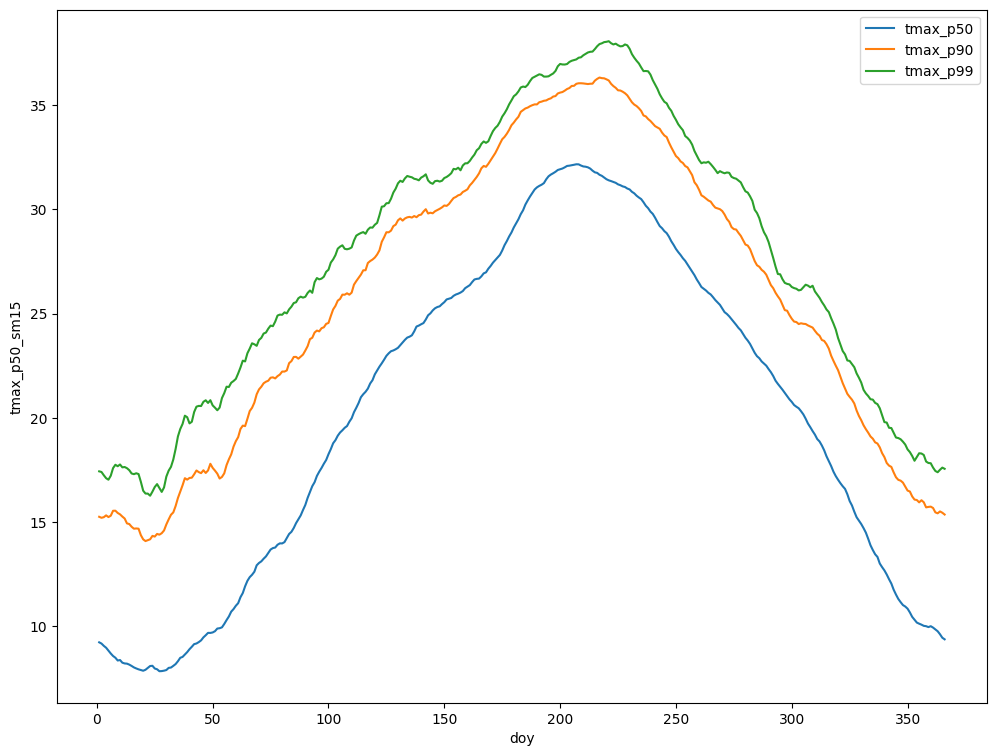

In [104]:

plt.figure(figsize=(12,9))
sns.lineplot(x='doy', y='tmax_p50_sm15', data=df_clim, label='tmax_p50');
sns.lineplot(x='doy', y='tmax_p95_sm15', data=df_clim, label='tmax_p90');
# sns.lineplot(x='doy', y='tmax_p95', data=df_clim, label='tmax_p95');
sns.lineplot(x='doy', y='tmax_p99_sm15', data=df_clim, label='tmax_p99');

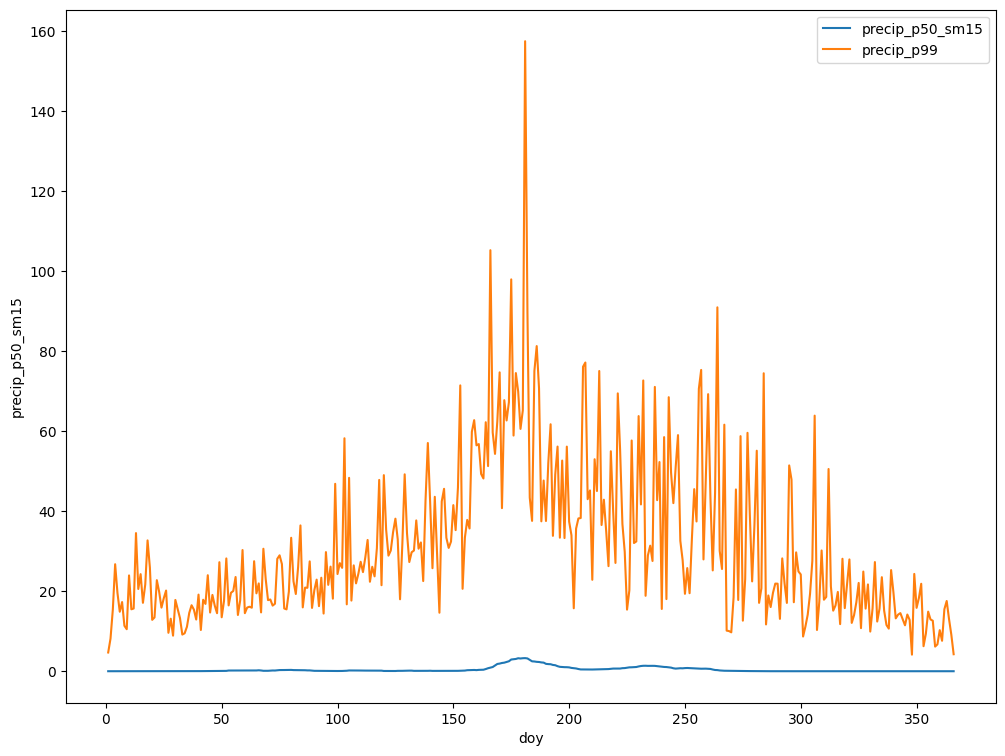

In [82]:

plt.figure(figsize=(12,9))
sns.lineplot(x='doy', y='precip_p50_sm15', data=df_clim, label='precip_p50_sm15');
sns.lineplot(x='doy', y='precip_p99', data=df_clim, label='precip_p99');

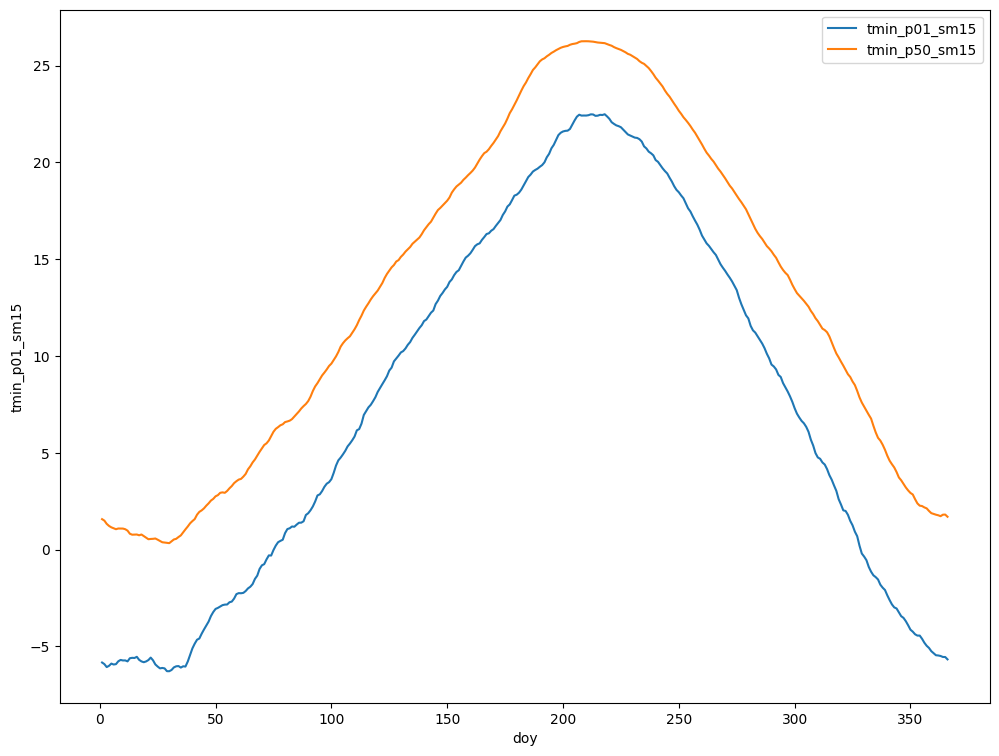

In [105]:

plt.figure(figsize=(12,9))
sns.lineplot(x='doy', y='tmin_p01_sm15', data=df_clim, label='tmin_p01_sm15');
sns.lineplot(x='doy', y='tmin_p50_sm15', data=df_clim, label='tmin_p50_sm15');


In [47]:
df_weather.columns

Index(['Unnamed: 0', 'time', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'precipitation_sum', 'precipitation_hours',
       'apparent_temperature_max', 'apparent_temperature_min',
       'sunshine_duration', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_speed_10m_mean', 'uv_index_max'],
      dtype='object')

In [45]:
df_weather.head()

,Unnamed: 0,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,apparent_temperature_max,apparent_temperature_min,sunshine_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,uv_index_max
0,0,1980-01-01,12.7,8.2,9.9,0.0,0.0,10.6,3.8,0.00,21.7,38.2,13.7,NaN
1,1,1980-01-02,8.9,5.4,6.5,3.0,8.0,7.8,2.1,0.00,15.4,28.1,11.9,NaN
2,2,1980-01-03,5.9,4.6,5.2,7.4,15.0,2.4,0.7,0.00,18.4,30.2,12.8,NaN
3,3,1980-01-04,5.4,-0.5,3.3,1.4,5.0,1.0,-5.8,15448.16,27.1,47.9,20.7,NaN
4,4,1980-01-05,4.0,-3.7,-0.1,0.0,0.0,0.5,-8.9,33514.38,18.4,31.7,10.6,NaN


In [46]:
df_weather.isna().sum()

Unnamed: 0                      0
time                            0
temperature_2m_max              0
temperature_2m_min              0
temperature_2m_mean             0
precipitation_sum               0
precipitation_hours             0
apparent_temperature_max        0
apparent_temperature_min        0
sunshine_duration               0
wind_speed_10m_max              0
wind_gusts_10m_max              0
wind_speed_10m_mean           365
uv_index_max                16802
dtype: int64

In [39]:
df_weather[~df_weather['apparent_temperature_max'].isna()].sort_values(by='apparent_temperature_max').tail(10)

,Unnamed: 0,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,apparent_temperature_max,apparent_temperature_min,sunshine_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,uv_index_max
12260,12260,2013-07-26,38.2,28.3,32.7,0.7,2.0,45.7,34.7,39796.88,11.5,25.9,6.7,NaN
12272,12272,2013-08-07,39.7,28.7,33.4,0.0,0.0,45.7,34.2,43565.46,16.0,29.9,10.6,NaN
8614,8614,2003-08-02,37.0,27.9,31.8,0.0,0.0,45.8,34.6,43414.75,14.1,26.3,8.7,NaN
15533,15533,2022-07-12,37.9,28.1,32.2,0.0,0.0,46.0,33.1,43337.75,17.0,31.3,11.5,NaN
16287,16287,2024-08-04,38.5,27.8,32.2,0.1,1.0,46.1,34.5,43349.66,15.7,28.1,10.3,NaN
15565,15565,2022-08-13,38.5,28.9,33.0,0.5,2.0,46.1,35.2,41136.04,13.7,39.6,11.0,NaN
8606,8606,2003-07-25,37.1,27.7,31.4,3.8,2.0,46.1,34.6,40144.11,7.8,17.6,3.6,NaN
16286,16286,2024-08-03,38.6,28.7,32.8,1.5,4.0,46.3,35.3,43321.30,14.2,27.4,7.3,NaN
15575,15575,2022-08-23,39.5,28.4,33.0,1.0,4.0,46.4,31.9,40436.75,21.9,39.2,10.3,NaN
3120,3120,1988-07-17,37.2,28.4,31.6,2.7,2.0,46.6,35.3,44626.78,11.6,27.0,8.8,NaN


In [40]:
df_weather[~df_weather['apparent_temperature_max'].isna()].sort_values(by='temperature_2m_max').tail(10)

,Unnamed: 0,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,apparent_temperature_max,apparent_temperature_min,sunshine_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,uv_index_max
16671,16671,2025-08-23,39.1,29.1,33.4,1.6,3.0,42.2,35.4,43200.00,13.0,33.8,7.8,NaN
12271,12271,2013-08-06,39.2,28.9,33.2,0.0,0.0,44.4,34.0,43654.99,17.6,31.3,12.0,NaN
15571,15571,2022-08-19,39.4,28.5,32.9,0.0,0.0,44.6,33.7,43200.00,18.7,36.7,15.5,NaN
15568,15568,2022-08-16,39.4,27.5,31.6,9.6,2.0,45.4,32.4,24689.20,17.7,38.9,11.8,NaN
12274,12274,2013-08-09,39.4,28.2,33.5,0.0,0.0,45.2,33.6,43339.41,13.8,26.3,8.4,NaN
15575,15575,2022-08-23,39.5,28.4,33.0,1.0,4.0,46.4,31.9,40436.75,21.9,39.2,10.3,NaN
16672,16672,2025-08-24,39.5,29.7,33.4,1.4,1.0,44.2,36.2,39600.00,10.4,31.0,7.7,NaN
12273,12273,2013-08-08,39.6,28.1,33.8,0.0,0.0,43.5,33.3,43570.52,16.9,30.6,10.3,NaN
12272,12272,2013-08-07,39.7,28.7,33.4,0.0,0.0,45.7,34.2,43565.46,16.0,29.9,10.6,NaN
15563,15563,2022-08-11,39.9,28.5,33.3,0.7,1.0,45.2,34.0,39971.64,14.1,24.8,10.8,NaN


In [41]:
df_weather[~df_weather['apparent_temperature_max'].isna()].sort_values(by='apparent_temperature_min').head(10)

,Unnamed: 0,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,apparent_temperature_max,apparent_temperature_min,sunshine_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,uv_index_max
30,30,1980-01-31,-4.6,-11.1,-8.1,0.0,0.0,-10.9,-17.7,35225.01,27.3,42.8,20.0,NaN
13172,13172,2016-01-24,-4.8,-8.5,-6.6,0.0,0.0,-11.9,-17.5,34757.29,37.5,69.8,28.2,NaN
29,29,1980-01-30,-0.0,-8.6,-5.1,0.0,0.0,-6.9,-16.2,4907.84,31.4,56.9,29.4,NaN
14983,14983,2021-01-08,-1.1,-8.7,-5.4,0.0,0.0,-8.1,-15.6,32747.84,22.7,46.1,17.6,NaN
35,35,1980-02-05,-2.0,-8.9,-5.8,0.0,0.0,-7.1,-14.9,35435.93,19.9,32.4,15.2,NaN
2196,2196,1986-01-05,-0.4,-8.1,-4.6,0.0,0.0,-6.9,-14.8,33543.43,25.5,45.0,18.7,NaN
4379,4379,1991-12-28,-1.8,-6.8,-4.2,0.0,0.0,-9.5,-14.7,33105.93,32.7,59.4,27.3,NaN
14982,14982,2021-01-07,1.6,-7.8,-4.1,0.0,0.0,-4.4,-14.6,17581.72,27.9,54.4,23.5,NaN
31,31,1980-02-01,-1.8,-9.1,-5.8,0.0,0.0,-7.0,-14.6,35264.40,17.0,25.6,12.9,NaN
13173,13173,2016-01-25,2.0,-7.3,-3.5,0.0,0.0,-4.2,-13.8,34844.03,21.3,40.0,15.9,NaN


## AQI

In [24]:
df_aqi.columns = [col.strip() for col in df_aqi.columns ]

In [26]:
df_aqi.sort_values(by='pm25')

,date,pm25,pm10,o3,no2,so2,co
4325,2013/12/31,,121,29,57,30,14
4323,2016/3/13,,61,51,13,8,7
4322,2017/9/10,,26,33,16,3,9
4321,2018/12/31,,34,26,13,4,3
4320,2019/12/31,,23,24,19,3,3
...,...,...,...,...,...,...,...
4102,2014/8/28,99,45,26,24,4,8
3863,2015/6/29,99,64,55,23,5,7
21,2026/1/22,99,53,16,21,3,7
932,2023/9/30,99,17,46,9,3,4
